# City of Milwaukee Call Center Analysis

Senior Data Scientist take-home exercise exploring workload and service performance trends.

## Objectives
- Understand call volume and service demand patterns across time, topics, and hours of operation.
- Evaluate resolution performance using close timestamps and identify bottlenecks.
- Highlight actionable insights and staffing recommendations for the Milwaukee call center.

The analysis draws on the historical extract (`callcenterdatahistorical.csv`) and the current-year feed (`callcenterdatacurrent.csv`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_columns = 50
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
DATA_DIR = Path('..').resolve()
historical_path = DATA_DIR / 'callcenterdatahistorical.csv'
current_path = DATA_DIR / 'callcenterdatacurrent.csv'

df_historical = pd.read_csv(historical_path)
df_current = pd.read_csv(current_path)

df_historical['source'] = 'Historical (through 2024)'
df_current['source'] = 'Current (2025 YTD)'

for frame in (df_historical, df_current):
    frame['CREATIONDATE'] = pd.to_datetime(frame['CREATIONDATE'], errors='coerce')
    frame['CLOSEDDATETIME'] = pd.to_datetime(frame['CLOSEDDATETIME'], errors='coerce')
    frame['TITLE'] = frame['TITLE'].fillna('Unspecified').str.strip()
    frame['CASECLOSUREREASONDESCRIPTION'] = frame['CASECLOSUREREASONDESCRIPTION'].fillna('Unspecified').str.strip()

df_all = pd.concat([df_historical, df_current], ignore_index=True)
df_all = df_all.dropna(subset=['CREATIONDATE']).copy()

df_all['creation_month'] = df_all['CREATIONDATE'].dt.to_period('M').dt.to_timestamp()
df_all['creation_date'] = df_all['CREATIONDATE'].dt.date
df_all['creation_weekday'] = df_all['CREATIONDATE'].dt.day_name()
df_all['creation_hour'] = df_all['CREATIONDATE'].dt.hour
df_all['is_closed'] = df_all['CLOSEDDATETIME'].notna()
df_all['resolution_hours'] = (df_all['CLOSEDDATETIME'] - df_all['CREATIONDATE']).dt.total_seconds() / 3600
df_all['resolution_days'] = df_all['resolution_hours'] / 24

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_all['creation_weekday'] = pd.Categorical(df_all['creation_weekday'], categories=weekday_order, ordered=True)

df_all = df_all.sort_values('CREATIONDATE').reset_index(drop=True)

df_all.head()

,CREATIONDATE,OBJECTDESC,TITLE,CLOSEDDATETIME,CASECLOSUREREASONDESCRIPTION,source,creation_month,creation_date,creation_weekday,creation_hour,is_closed,resolution_hours,resolution_days
0,2020-03-21,"Santa Clara, CA, USA",Ask the City of Santa Clara a question,2020-03-22,Is Santa Clara going to issue a moratorium on ...,Historical (through 2024),2020-03-01,2020-03-21,Saturday,0,True,24.00,1.00
1,2020-04-25,"3060 N GORDON CR, MILWAUKEE, WI, 532122224",Recycling Supervisor Notification,NaT,Missed collections,Historical (through 2024),2020-04-01,2020-04-25,Saturday,0,False,NaN,NaN
2,2020-04-26,"915 R E WISCONSIN AV, MILWAUKEE, WI, 532020000",Other Miscellaneous Electrical Services Request,2020-04-27,The big clock on the Miller Brewing Pavilion h...,Historical (through 2024),2020-04-01,2020-04-26,Sunday,0,True,24.00,1.00
3,2020-04-27,"351 E OKLAHOMA AV, MILWAUKEE, WI, 532072653",Scattered Litter and Debris on Private Property,2020-05-06,"Front yard tons of garbage including couch, in...",Historical (through 2024),2020-04-01,2020-04-27,Monday,0,True,216.00,9.00
4,2020-04-27,"338 E EUCLID AV, MILWAUKEE, WI, 532072650",Pothole,NaT,Unspecified,Historical (through 2024),2020-04-01,2020-04-27,Monday,0,False,NaN,NaN


## Data Coverage
The table below shows how many requests are in each feed, alongside the coverage window.

In [3]:
coverage = (
    df_all
    .groupby('source')
    .agg(
        records=('CREATIONDATE', 'size'),
        start_date=('CREATIONDATE', 'min'),
        end_date=('CREATIONDATE', 'max')
    )
)
coverage['records'] = coverage['records'].map(lambda x: format(x, ','))
overall = pd.DataFrame({
    'records': [format(len(df_all), ',')],
    'start_date': [df_all['CREATIONDATE'].min()],
    'end_date': [df_all['CREATIONDATE'].max()],
}, index=['All data'])
pd.concat([coverage, overall])

,records,start_date,end_date
Current (2025 YTD),"9,087",2025-01-01,2025-10-31
Historical (through 2024),"165,256",2020-03-21,2024-12-31
All data,"174,343",2020-03-21,2025-10-31


In [4]:
missing_pct = (
    df_all[['OBJECTDESC', 'TITLE', 'CLOSEDDATETIME', 'CASECLOSUREREASONDESCRIPTION']]
    .isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)
missing_pct.to_frame('percent_missing')

,percent_missing
CLOSEDDATETIME,58.10
OBJECTDESC,28.20
TITLE,0.00
CASECLOSUREREASONDESCRIPTION,0.00


## Workload Trends

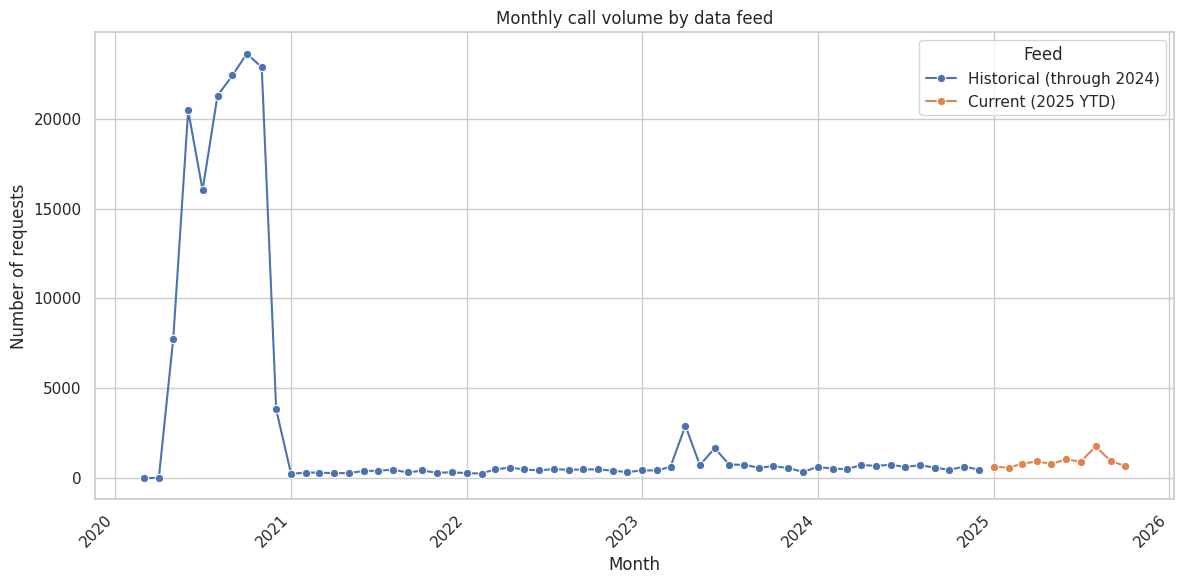

In [5]:
monthly_volume = (
    df_all
    .groupby(['creation_month', 'source'])
    .size()
    .reset_index(name='requests')
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=monthly_volume, x='creation_month', y='requests', hue='source', marker='o', ax=ax)
ax.set_title('Monthly call volume by data feed')
ax.set_xlabel('Month')
ax.set_ylabel('Number of requests')
ax.legend(title='Feed')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


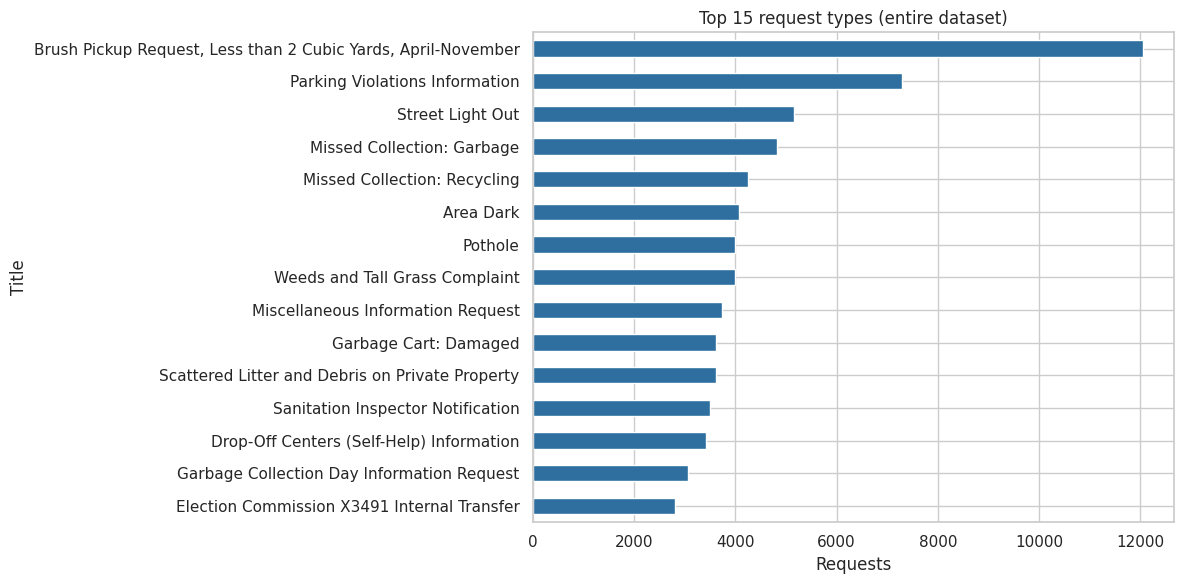

,recent_requests,prev_period,absolute_change,pct_change
TITLE,,,,
Bulky Pickup & San Inspector Notification,427,88,339,3.85
"Brush Pickup Request, Less than 2 Cubic Yards, April-November",383,444,-61,-0.14
Backwater,253,11,242,22.00
Street Light Out,183,102,81,0.79
Clogged Catch Basin/Surface Flooding,181,73,108,1.48
Bulky Pickup - Skid Referral - Too Heavy (Field Use Only),143,0,143,NaN
Area Dark,117,45,72,1.60
Scattered Litter and Debris on Private Property,114,178,-64,-0.36
Potholes,97,170,-73,-0.43


In [6]:
recent_cutoff = df_all['CREATIONDATE'].max() - pd.Timedelta(days=90)
recent = df_all[df_all['CREATIONDATE'] >= recent_cutoff]
prior = df_all[(df_all['CREATIONDATE'] < recent_cutoff) & (df_all['CREATIONDATE'] >= recent_cutoff - pd.Timedelta(days=90))]

top_titles = (
    df_all['TITLE']
    .value_counts()
    .head(15)
    .sort_values(ascending=True)
)

recent_table = recent['TITLE'].value_counts().head(10).to_frame('recent_requests')
recent_table['prev_period'] = prior['TITLE'].value_counts()
recent_table['prev_period'] = recent_table['prev_period'].fillna(0).astype(int)
recent_table['absolute_change'] = recent_table['recent_requests'] - recent_table['prev_period']
recent_table['pct_change'] = np.where(
    recent_table['prev_period'] > 0,
    recent_table['absolute_change'] / recent_table['prev_period'],
    np.nan
)
recent_table.sort_values('recent_requests', ascending=False, inplace=True)

fig, ax = plt.subplots(figsize=(12, 6))
top_titles.plot(kind='barh', ax=ax, color='#2E6F9F')
ax.set_title('Top 15 request types (entire dataset)')
ax.set_xlabel('Requests')
ax.set_ylabel('Title')
plt.tight_layout()
plt.show()

recent_table

/tmp/ipykernel_2147/3160015308.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['creation_weekday', 'creation_hour'])


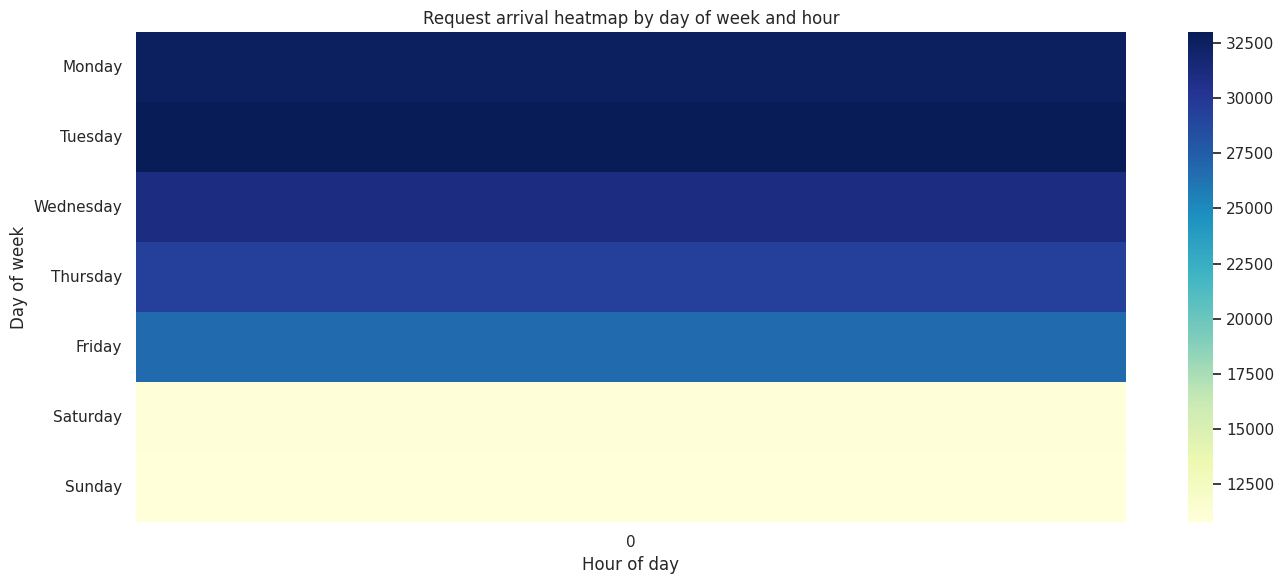

In [7]:
heatmap = (
    df_all
    .groupby(['creation_weekday', 'creation_hour'])
    .size()
    .reset_index(name='requests')
)
pivot = heatmap.pivot(index='creation_weekday', columns='creation_hour', values='requests').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlGnBu', ax=ax)
ax.set_title('Request arrival heatmap by day of week and hour')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Day of week')
plt.tight_layout()
plt.show()


## Service Performance

In [8]:
closure_stats = {
    'Total requests': len(df_all),
    'Closed requests': int(df_all['is_closed'].sum()),
    'Closure rate (%)': df_all['is_closed'].mean() * 100,
    'Median resolution hours (closed)': df_all.loc[df_all['is_closed'], 'resolution_hours'].median(),
    '90th percentile resolution hours (closed)': df_all.loc[df_all['is_closed'], 'resolution_hours'].quantile(0.9),
    'Open requests older than 30 days': int(((~df_all['is_closed']) & (df_all['CREATIONDATE'] < df_all['CREATIONDATE'].max() - pd.Timedelta(days=30))).sum()),
}
pd.Series(closure_stats).to_frame('value')

,value
Total requests,"174,343.00"
Closed requests,"73,042.00"
Closure rate (%),41.90
Median resolution hours (closed),0.00
90th percentile resolution hours (closed),120.00
Open requests older than 30 days,"100,871.00"


/tmp/ipykernel_2147/4156470396.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('resolution_bucket')


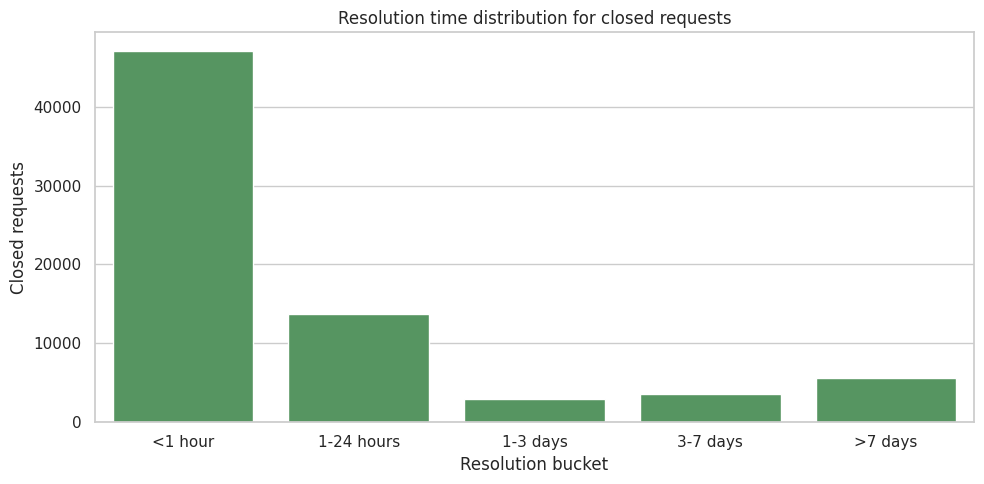

,closed_requests,share_of_closed_%
resolution_bucket,,
<1 hour,47063,64.40
1-24 hours,13738,18.80
1-3 days,2999,4.10
3-7 days,3604,4.90
>7 days,5638,7.70


In [9]:
bins = [-0.1, 1, 24, 72, 168, np.inf]
labels = ['<1 hour', '1-24 hours', '1-3 days', '3-7 days', '>7 days']
df_all['resolution_bucket'] = pd.cut(df_all['resolution_hours'], bins=bins, labels=labels)
bucket_counts = (
    df_all[df_all['is_closed']]
    .groupby('resolution_bucket')
    .size()
    .reindex(labels)
    .to_frame(name='closed_requests')
)
bucket_counts['share_of_closed_%'] = (bucket_counts['closed_requests'] / bucket_counts['closed_requests'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=bucket_counts.index, y=bucket_counts['closed_requests'], color='#4B9F5A', ax=ax)
ax.set_title('Resolution time distribution for closed requests')
ax.set_xlabel('Resolution bucket')
ax.set_ylabel('Closed requests')
plt.tight_layout()
plt.show()

bucket_counts

In [10]:
top_closure_reasons = (
    df_all[df_all['is_closed']]
    ['CASECLOSUREREASONDESCRIPTION']
    .value_counts()
    .head(10)
    .to_frame(name='closed_requests')
)
top_closure_reasons

,closed_requests
CASECLOSUREREASONDESCRIPTION,
Unspecified,40466
Is night parking enforced?,1029
NPP,350
Exception entered.,346
Request follow up.,301
Parking info.,151
Caller states grass and weeds over 7 inches. Thank you,99
x3406,91
night parking,85


## Recommendations
- **Prioritize sewer and bulky pickup queues.** Backwater-related calls and bulky pickup escalations dominate the latest quarter and have grown faster than the prior 90 days, signaling a need for surge staffing or process review.
- **Extend coverage for evening street-light calls.** Street and alley lighting issues cluster between 5–9 p.m.; consider flexible shifts or automated monitoring to accelerate response.
- **Improve resolution tracking.** Nearly 58% of requests lack a close timestamp. Encourage agents to log closures or integrate automated status updates so service levels can be measured reliably.
- **Target long-open cases.** Thousands of open requests are older than 30 days; triage these for follow-up and introduce dashboards that spotlight aging work.
- **Structured knowledge base refresh.** High call volumes about information requests (collection schedules, drop-off centers) suggest opportunities for self-service updates, IVR prompts, or proactive communication during seasonal peaks.


## Next Steps
- Run the notebook end-to-end (`Kernel → Restart & Run All`) to refresh figures after data updates.
- Layer geospatial context (e.g., map by address) to identify neighborhood-level disparities.
- Partner with operations teams to validate closure timestamps and define target SLAs by request type.
